In [1]:
import experiment_utils
from experiment_utils import config

config.experiment_name = "inHomo_complexHelmholtz_dirichlet_2d"
config.target = "jmlr_docker"
config.debug_mode = True

In [2]:
import numpy as np
import probnum as pn
import linpde_gp
from linpde_gp.utils import to_real2, from_real2

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
import matplotlib.pyplot as plt
from matplotlib import patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

In [4]:
%matplotlib inline

In [5]:
plt.style.use('default')
plt.rcParams.update(config.tueplots_bundle())
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = True

In [6]:
cmap_mean = 'plasma'
cmap_uncertainty = 'viridis'
cmap_diverging = 'RdBu_r' 

In [7]:
def _k2_str(k2):
    """Format a (possibly complex) kappa^2 for LaTeX labels."""
    k2 = complex(k2)
    return rf"{k2.real:.2f}{k2.imag:+.2f}\,\mathrm{{i}}"


def plot_problem_setup(bvp, X_bc_list, X_pde):
    """Visualize the computational domain with boundary and PDE observation points."""
    fig = plt.figure(figsize=(7, 6))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1],
                           hspace=0.35, wspace=0.35, figure=fig)

    # Domain with observation points (2D view)
    ax1 = fig.add_subplot(gs[0, :])

    domain_box = patches.Rectangle(
        (-1, -1), 2, 2, linewidth=2,
        edgecolor='black', facecolor='none', linestyle='-'
    )
    ax1.add_patch(domain_box)

    for i, X_bc in enumerate(X_bc_list):
        ax1.scatter(X_bc[:, 0], X_bc[:, 1], s=50, marker='o',
                   c=f'C{i}', edgecolors='black', linewidth=0.5,
                   label=f'Boundary {i+1}', zorder=5, alpha=0.8)

    X_pde_flat = X_pde.reshape(-1, 2)
    ax1.scatter(X_pde_flat[:, 0], X_pde_flat[:, 1], s=30, marker='s',
               c='darkred', edgecolors='black', linewidth=0.5,
               label='PDE collocation', zorder=4, alpha=0.7)

    ax1.set_xlim(-1.2, 1.2)
    ax1.set_ylim(-1.2, 1.2)
    ax1.set_xlabel(r'$x_1$', fontsize=11)
    ax1.set_ylabel(r'$x_2$', fontsize=11)
    ax1.set_title('(a) Computational Domain and Observation Points',
                  fontsize=12, fontweight='bold', loc='left')
    ax1.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='gray')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    ax2 = fig.add_subplot(gs[1, 0])

    n_boundary = sum(len(X_bc) for X_bc in X_bc_list)
    n_pde = len(X_pde_flat)

    categories = ['Boundary\nConditions', 'PDE\nCollocation', 'Total']
    counts = [n_boundary, n_pde, n_boundary + n_pde]
    colors = ['steelblue', 'darkred', 'gray']

    bars = ax2.bar(categories, counts, color=colors, alpha=0.7,
                   edgecolor='black', linewidth=0.8)

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{int(count)}', ha='center', va='bottom', fontsize=9)

    ax2.set_ylabel('Number of Observations', fontsize=10)
    ax2.set_title('(b) Observation Counts', fontsize=12,
                  fontweight='bold', loc='left')
    ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.set_ylim(0, max(counts) * 1.15)

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')

    k2 = complex(bvp.pde.k_squared)
    info_text = (
        r'$\textbf{Problem Parameters:}$' + '\n\n'
        r'Domain: $\Omega = [-1, 1]^2$' + '\n'
        r'Equation: $\Delta u + \kappa^2 u = f$' + '\n'
        r'(complex-valued $u, f, \kappa^2$)' + '\n'
        rf'$\rho = {bvp.pde.rho:.1f}$, $\omega = {bvp.pde.omega:.1f}$' + '\n'
        rf'$G^\prime = {bvp.pde.G_complex.real:.1f}$, '
        rf'$G^{{\prime\prime}} = {bvp.pde.G_complex.imag:.1f}$' + '\n'
        rf'$\kappa^2 = {_k2_str(k2)}$' + '\n\n'
        r'$\textbf{Discretization:}$' + '\n'
        f'Boundary points: {n_boundary}\n'
        f'Interior points: {n_pde}\n'
        f'Total observations: {n_boundary + n_pde}'
    )

    ax3.text(0.05, 0.95, info_text, transform=ax3.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3,
                     edgecolor='gray', linewidth=0.8))

    return fig

In [8]:
def plot_posterior_solution(
    plt_grid, u_post, X_pde=None, X_bc_list=None,
    extent=(-1, 1, -1, 1), figsize=(5.5, 4.2),
    show_domain_outline=True,
):
    """Posterior mean and 95% credible half-width for a complex (real2) field.

    Same visual language as the real-valued 2D example (plasma mean panels,
    viridis uncertainty panels, white domain outline + observation overlays),
    extended to two rows: real part (top) and imaginary part (bottom).
    """
    grid_coords = np.asarray(plt_grid)
    Ny, Nx = grid_coords.shape[:2]
    X_flat = grid_coords.reshape(-1, 2)

    cond_explicit = []
    if X_bc_list is not None:
        cond_explicit.append(r'$u|_{\partial \Omega} = g$')
    if X_pde is not None:
        cond_explicit.append(r'$(\Delta + \kappa^2) u(\mathbf{x}_i) = f(\mathbf{x}_i)$')

    # mean: (Ny, Nx, 2) -> (Re, Im)
    u_mean = np.asarray(u_post.mean(grid_coords)).reshape(Ny, Nx, 2)
    mean_parts = [u_mean[..., 0], u_mean[..., 1]]

    with np.errstate(invalid='ignore'):
        u_std = np.asarray(u_post.std(X_flat)).reshape(Ny, Nx, 2)
    u_std = np.maximum(np.nan_to_num(u_std, nan=0.0), 0.0)
    ci_parts = [1.96 * u_std[..., 0], 1.96 * u_std[..., 1]]

    part_tags = [r'\mathrm{Re}', r'\mathrm{Im}']
    panel_letters = [['a', 'b'], ['c', 'd']]

    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)

    for r in range(2):
        # mean panel
        im1 = axes[r, 0].imshow(
            mean_parts[r], cmap='plasma', extent=extent, origin='lower',
            aspect='equal', interpolation='bilinear'
        )
        axes[r, 0].set_title(rf'\textbf{{{panel_letters[r][0]}}}', loc='left', fontweight='bold')
        cbar1 = fig.colorbar(im1, ax=axes[r, 0], fraction=0.046, pad=0.04)
        cbar1.set_label(rf'${part_tags[r]}\,\mathbb{{E}}[u \mid \mathcal{{I}}]$')

        # uncertainty panel
        im2 = axes[r, 1].imshow(
            ci_parts[r], cmap='viridis', extent=extent, origin='lower',
            aspect='equal', interpolation='bilinear', vmin=0
        )
        axes[r, 1].set_title(rf'\textbf{{{panel_letters[r][1]}}}', loc='left', fontweight='bold')
        cbar2 = fig.colorbar(im2, ax=axes[r, 1], fraction=0.046, pad=0.04)
        cbar2.set_label(rf'$1.96\,\sigma[{part_tags[r]}\,u \mid \mathcal{{I}}]$')

    for ax in axes.ravel():
        ax.set_xlabel(r'$x_1$')
        ax.set_ylabel(r'$x_2$')
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        if show_domain_outline:
            ax.add_patch(
                patches.Rectangle(
                    (extent[0], extent[2]), extent[1] - extent[0], extent[3] - extent[2],
                    linewidth=1.0, edgecolor='white', facecolor='none', alpha=0.7,
                )
            )

    if cond_explicit:
        # Real and imaginary parts are conditioned jointly on the same information
        # set I, so the same annotation is mirrored on both mean panels (a) and (c).
        cond_text = r'$\mathcal{I}$: ' + ', '.join(cond_explicit)
        for r in range(2):
            axes[r, 0].text(
                0.02, 0.98, cond_text, transform=axes[r, 0].transAxes,
                fontsize=6, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                         alpha=0.6, edgecolor='gray', linewidth=0.3)
            )

    for ax in axes.ravel():
        if X_pde is not None:
            X_pde_flat = np.asarray(X_pde).reshape(-1, 2)
            ax.scatter(X_pde_flat[:, 0], X_pde_flat[:, 1],
                      s=4, c='black', alpha=0.3, linewidth=0, marker='o')
        if X_bc_list is not None:
            for X_bc in X_bc_list:
                X_bc = np.asarray(X_bc).reshape(-1, 2)
                ax.scatter(X_bc[:, 0], X_bc[:, 1],
                          s=12, c='black', alpha=0.5, linewidth=0.8, marker='x')
    return fig

In [9]:
def plot_pde_satisfaction(
    plt_grid, u_post, bvp, X_pde=None,
    extent=(-1, 1, -1, 1), figsize=(8, 4.2),
    show_domain_outline=True,
):
    """Visualize how well the posterior satisfies the complex Helmholtz PDE.

    Columns: (a) E[(Delta + kappa^2) u | I], (b) true RHS f, (c) residual.
    Rows: real part (top) and imaginary part (bottom). Same colormaps as the
    real-valued example (plasma for operator/RHS, RdBu_r centered at 0 for the
    residual).
    """
    grid_coords = np.asarray(plt_grid)
    Ny, Nx = grid_coords.shape[:2]

    helmholtz_u_post = bvp.pde.diffop(u_post)
    Lu_mean = np.asarray(helmholtz_u_post.mean(grid_coords)).reshape(Ny, Nx, 2)
    f_true = np.asarray(bvp.pde.rhs(grid_coords)).reshape(Ny, Nx, 2)
    residual = Lu_mean - f_true

    k2 = complex(bvp.pde.k_squared)
    k2s = _k2_str(k2)
    part_tags = [r'\mathrm{Re}', r'\mathrm{Im}']
    panel_letters = [['a', 'b', 'c'], ['d', 'e', 'f']]

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)

    for r in range(2):
        Lu = Lu_mean[..., r]
        f_r = f_true[..., r]
        res_r = residual[..., r]

        im1 = axes[r, 0].imshow(Lu, cmap='plasma', extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear')
        axes[r, 0].set_title(rf'\textbf{{{panel_letters[r][0]}}}', loc='left', fontweight='bold')
        cbar1 = fig.colorbar(im1, ax=axes[r, 0], fraction=0.046, pad=0.04)
        cbar1.set_label(rf'${part_tags[r]}\,\mathbb{{E}}[(\Delta + ({k2s})) u \mid \mathcal{{I}}]$')

        im2 = axes[r, 1].imshow(f_r, cmap='plasma', extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear')
        axes[r, 1].set_title(rf'\textbf{{{panel_letters[r][1]}}}', loc='left', fontweight='bold')
        cbar2 = fig.colorbar(im2, ax=axes[r, 1], fraction=0.046, pad=0.04)
        cbar2.set_label(rf'${part_tags[r]}\,f(\mathbf{{x}})$')

        vmax_res = np.max(np.abs(res_r)) if np.max(np.abs(res_r)) > 0 else 1.0
        im3 = axes[r, 2].imshow(res_r, cmap='RdBu_r', extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear',
                                vmin=-vmax_res, vmax=vmax_res)
        axes[r, 2].set_title(rf'\textbf{{{panel_letters[r][2]}}}', loc='left', fontweight='bold')
        cbar3 = fig.colorbar(im3, ax=axes[r, 2], fraction=0.046, pad=0.04)
        cbar3.set_label(rf'${part_tags[r]}$ residual')

    for ax in axes.ravel():
        ax.set_xlabel(r'$x_1$')
        ax.set_ylabel(r'$x_2$')
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        if show_domain_outline:
            ax.add_patch(
                patches.Rectangle(
                    (extent[0], extent[2]), extent[1] - extent[0], extent[3] - extent[2],
                    linewidth=1.0, edgecolor='white', facecolor='none', alpha=0.7,
                )
            )

    if X_pde is not None:
        X_pde_flat = np.asarray(X_pde).reshape(-1, 2)
        for ax in axes.ravel():
            ax.scatter(X_pde_flat[:, 0], X_pde_flat[:, 1],
                      s=6, c='black', alpha=0.4, linewidth=0, marker='o')

    return fig

In [10]:
rng = np.random.default_rng(24)

## Problem Definition

We solve the **complex-valued** inhomogeneous Helmholtz equation on $\Omega = [-1,1]^2$
with homogeneous Dirichlet boundary conditions,
$$\Delta u(\mathbf{x}) + \kappa^2 u(\mathbf{x}) = f(\mathbf{x}), \qquad u|_{\partial\Omega} = 0,$$
where the wavenumber squared $\kappa^2 = \rho\,\omega^2 / (G' + \mathrm{i}\,G'')$ is **complex**
whenever the loss modulus $G'' \neq 0$. This is the 2D analogue of the 1D complex example.

The complex field is represented in the `real2` convention: $u = (\mathrm{Re}\,u,\ \mathrm{Im}\,u)$.
Splitting $\kappa^2 = \alpha + \mathrm{i}\beta$, the single complex PDE becomes the coupled real
$2\times 2$ block system
$$\begin{bmatrix}\Delta + \alpha & -\beta \\ \beta & \Delta + \alpha\end{bmatrix}
\begin{bmatrix}\mathrm{Re}\,u \\ \mathrm{Im}\,u\end{bmatrix}
=\begin{bmatrix}\mathrm{Re}\,f \\ \mathrm{Im}\,f\end{bmatrix},$$
which `HelmholtzReal2Operator` builds. The Laplacian is dimension-agnostic, so the construction is
identical to 1D — only the domain changes.

In [11]:
rho, omega, Gp, Gpp = 1.0, 1.0, 1.0, 0.5  # Gpp != 0 => complex kappa^2

In [12]:
bvp = linpde_gp.problems.pde.HelmholtzEquationDirichletProblem(
    domain=linpde_gp.domains.Box([[-1.0, 1.0], [-1.0, 1.0]]),
    rho=rho,
    omega=omega,
    G_real=Gp,
    G_imag=Gpp,
    rhs=linpde_gp.functions.Constant(input_shape=(2,), value=to_real2(2.0 + 0.0j)),
    boundary_values=linpde_gp.functions.Constant(input_shape=(2,), value=to_real2(0.0)),
    complex_representation="real2",
)
print("kappa^2 =", bvp.pde.k_squared)
print("operator:", type(bvp.pde.diffop).__name__)

kappa^2 = (0.8-0.4j)
operator: HelmholtzReal2Operator


In [13]:
plt_grid = bvp.domain.uniform_grid((50, 50))

## Gaussian Process Prior

The prior places an independent, identically-scaled GP on the real and imaginary parts via
`Real2FromScalarKernel`, which wraps the scalar 2D tensor-product `ExpQuad` kernel into a
block-diagonal $(\mathrm{Re}, \mathrm{Im})$ kernel. This is exactly the 1D construction with a
2D base kernel.

In [14]:
prior_gp = pn.randprocs.GaussianProcess(
    mean=linpde_gp.functions.Zero(input_shape=(2,), output_shape=(2,)),
    cov=linpde_gp.randprocs.covfuncs.Real2FromScalarKernel(
        2.0 ** 2 * linpde_gp.randprocs.covfuncs.TensorProduct(
            linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
            linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
        )
    ),
)

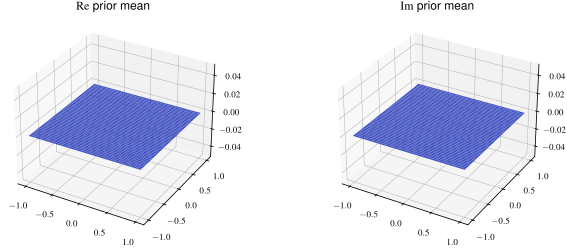

In [15]:
prior_mean = prior_gp.mean(plt_grid)  # (50, 50, 2)

fig, axes = plt.subplots(1, 2, subplot_kw={"projection": "3d"}, figsize=(9, 3.5),
                         constrained_layout=True)
for ax, k, name in zip(axes, [0, 1], ["Re", "Im"]):
    ax.plot_surface(plt_grid[..., 0], plt_grid[..., 1], prior_mean[..., k], cmap="coolwarm")
    ax.set_title(rf"$\mathrm{{{name}}}$ prior mean")

## Conditioning on Boundary Conditions

**Note on the noise model (the one real2-specific subtlety).** Exactly as in the real-valued
example, each observation gets a small jitter term `b` for numerical stability (a dense
boundary grid is otherwise near-singular, and the jitter also lets us evaluate the posterior
*covariance*, not just the mean).

There is one bookkeeping detail unique to the vector-valued `real2` GP. For a batch of `N`
points the measurement output is `(2, N)`, and `probnum.randvars.Normal` only supports jitter
covariances up to 2-D. So we pass the collocation points as a **flat** `(N, 2)` batch (rather
than an `(N_x, N_y)` grid, whose measurement output `(2, N_x, N_y)` would be a 3-axis tensor
that `Normal` cannot represent). Flattening keeps the jitter valid for both the boundary and the
PDE constraints. This is purely a shape convention — the model is identical.

In [16]:
def _normalize_real2_xy(X, Y, d=2):
    X = np.asarray(X).reshape(-1, d)
    Y = np.asarray(Y).reshape(-1, 2)  # (N, 2) real2 targets
    return X, Y

N_bc = 20
bc_jitter = 1e-7  # regularizes the (otherwise near-singular) boundary Gram
u_bc = prior_gp
X_bc_list = []

for boundary_condition in bvp.boundary_conditions:
    X_bc = boundary_condition.boundary.uniform_grid(N_bc, inset=1e-6)
    Y_bc = boundary_condition.values(X_bc)          # real2 -> (N, 2)
    X_bc, Y_bc = _normalize_real2_xy(X_bc, Y_bc, d=2)
    X_bc_list.append(X_bc)

    assert X_bc.shape == (N_bc, 2)
    assert Y_bc.shape == (N_bc, 2)

    # BC measurement output is shaped (2, N_bc) -> a 2D Normal jitter is valid here.
    b_bc = pn.randvars.Normal(
        mean=np.zeros((2, N_bc)),
        cov=bc_jitter * np.eye(2 * N_bc),
    )
    u_bc = u_bc.condition_on_observations(Y_bc, X=X_bc, b=b_bc)

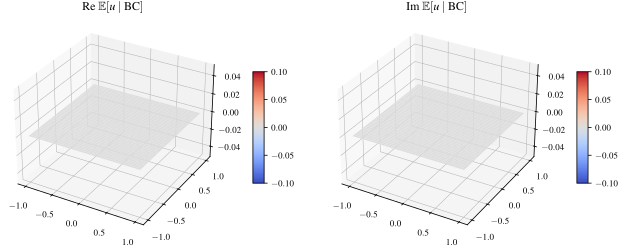

In [17]:
u_bc_mean = u_bc.mean(plt_grid)  # (50, 50, 2)

fig, axes = plt.subplots(1, 2, subplot_kw={"projection": "3d"}, figsize=(9, 3.5),
                         constrained_layout=True)
for ax, k, name in zip(axes, [0, 1], ["Re", "Im"]):
    surf = ax.plot_surface(plt_grid[..., 0], plt_grid[..., 1], u_bc_mean[..., k], cmap="coolwarm")
    ax.set_title(rf"$\mathrm{{{name}}}\; \mathbb{{E}}[u \mid \mathrm{{BC}}]$")
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

### Conditioning on PDE Observations

In [18]:
N_pde = 10
pde_jitter = 1e-4  # stabilizes the joint Gram so the posterior covariance is available

# Flat (N_pde^2, 2) batch of collocation points -> measurement output is (2, N) (2-D),
# which keeps the Normal jitter valid (see the note above).
X_pde = np.asarray(bvp.domain.uniform_grid((N_pde, N_pde), inset=1e-6)).reshape(-1, 2)
Y_pde = np.asarray(bvp.pde.rhs(X_pde))  # (N_pde^2, 2) real2
n_pde = X_pde.shape[0]

b_pde = pn.randvars.Normal(
    mean=np.zeros((2, n_pde)),
    cov=pde_jitter * np.eye(2 * n_pde),
)

u_bc_pde = u_bc.condition_on_observations(
    Y=Y_pde,
    L=bvp.pde.diffop,
    X=X_pde,
    b=b_pde,
)

### Visualization

Figure 1: Problem Setup...


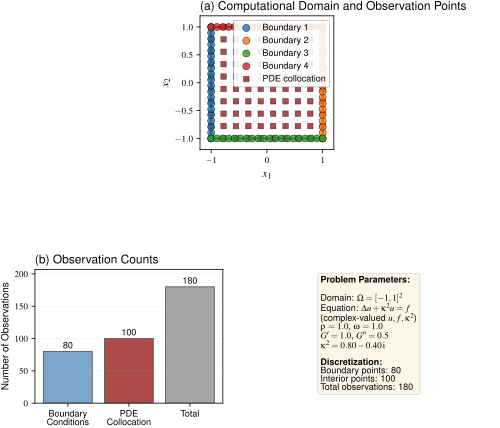

In [19]:
print("Figure 1: Problem Setup...")
fig1 = plot_problem_setup(bvp, X_bc_list, X_pde)
plt.show()

Figure 2: Posterior Solution (2D, complex)...


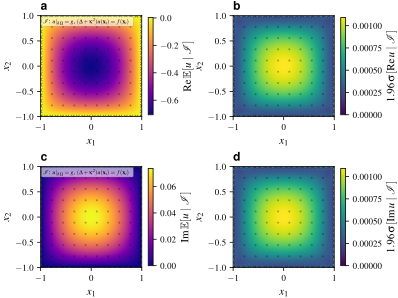

In [20]:
print("Figure 2: Posterior Solution (2D, complex)...")
fig2 = plot_posterior_solution(plt_grid, u_bc_pde, X_pde=X_pde, X_bc_list=X_bc_list)
fig2.savefig('./helmholtz2d_complex_posterior_100pts.pdf', bbox_inches='tight')
plt.show()

Figure 3: PDE Satisfaction Analysis (complex)...


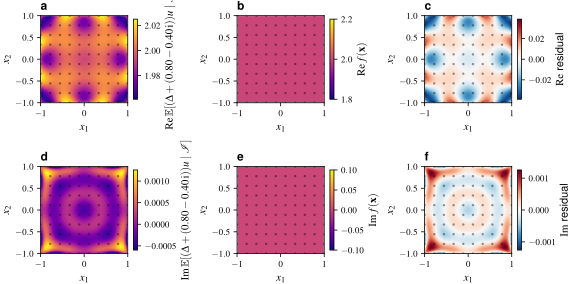

In [21]:
print("Figure 3: PDE Satisfaction Analysis (complex)...")
fig3 = plot_pde_satisfaction(plt_grid, u_bc_pde, bvp, X_pde=X_pde)
fig3.savefig('./helmholtz2d_complex_pde_residual_100pts.pdf', bbox_inches='tight')
plt.show()

## Evaluation against the analytical complex solution

For a constant complex source $f$ on $[-1,1]^2$ with homogeneous Dirichlet data, the solution
admits a sine eigenfunction expansion. The series coefficients carry the complex $\kappa^2$ through
$(-\lambda_{mn} + \kappa^2)^{-1}$, so the same routine used for the real case returns a complex
field when given a complex $\kappa^2$.

In [22]:
def analytical_constant_source(X, Y, k_squared=1.0, f0=2.0, M=101, N=101):
    """Sine-series solution of (Delta + kappa^2) u = f0 on [-1,1]^2, u=0 on boundary.

    Works for complex k_squared and complex f0 (returns a complex field).
    """
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    dtype = complex if (np.iscomplexobj(k_squared) or np.iscomplexobj(f0)) else float
    u = np.zeros_like(X, dtype=dtype)

    for m in range(1, M, 2):
        for n in range(1, N, 2):
            lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2
            denom = -lam + k_squared
            coeff = f0 * 16.0 / (np.pi ** 2 * m * n * denom)
            u += coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta)

    return u


nx, ny = 31, 31
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y, indexing="ij")
pts = np.hstack([X.reshape(-1, 1), Y.reshape(-1, 1)])

pred_real2 = u_bc_pde.mean(pts).reshape(nx, ny, 2)
pred_re = pred_real2[..., 0]
pred_im = pred_real2[..., 1]
pred_complex = pred_re + 1j * pred_im

k_squared = complex(bvp.pde.k_squared)
u_true = analytical_constant_source(X, Y, k_squared=k_squared, f0=2.0, M=101, N=101)
true_re, true_im = np.real(u_true), np.imag(u_true)


def _metrics(pred, true):
    pred = np.asarray(pred).ravel(); true = np.asarray(true).ravel()
    err = np.abs(pred - true)
    denom = np.linalg.norm(true)
    return {
        "mse": float(np.mean(err ** 2)),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "mae": float(np.mean(err)),
        "max_error": float(np.max(err)),
        "relative_l2": float(np.linalg.norm(err) / denom) if denom > 0 else np.inf,
    }


m_re = _metrics(pred_re, true_re)
m_im = _metrics(pred_im, true_im)
m_cplx = _metrics(pred_complex, u_true)


def _print_block(title, m):
    print(f"\n  --- {title} ---")
    print(f"    Relative L2 Error:   {m['relative_l2']:12.6e}")
    print(f"    RMSE:                {m['rmse']:12.6e}")
    print(f"    MAE:                 {m['mae']:12.6e}")
    print(f"    Maximum Error:       {m['max_error']:12.6e}")
    print(f"    MSE:                 {m['mse']:12.6e}")


print("=" * 60)
print("EVALUATION METRICS - Complex Helmholtz 2D".center(60))
print(f"  Grid: {nx}x{ny}   kappa^2 = {k_squared:.4f}")
print("=" * 60)
_print_block("Real Part", m_re)
_print_block("Imaginary Part", m_im)
_print_block("Complex |u|", m_cplx)
print("\n" + "=" * 60)

         EVALUATION METRICS - Complex Helmholtz 2D          
  Grid: 31x31   kappa^2 = 0.8000-0.4000j

  --- Real Part ---
    Relative L2 Error:   1.655264e-03
    RMSE:                6.245027e-04
    MAE:                 3.400345e-04
    Maximum Error:       2.836402e-03
    MSE:                 3.900036e-07

  --- Imaginary Part ---
    Relative L2 Error:   1.669903e-04
    RMSE:                6.073244e-06
    MAE:                 4.537998e-06
    Maximum Error:       1.720247e-05
    MSE:                 3.688429e-11

  --- Complex |u| ---
    Relative L2 Error:   1.647704e-03
    RMSE:                6.245322e-04
    MAE:                 3.401727e-04
    Maximum Error:       2.836416e-03
    MSE:                 3.900405e-07

